# Chapter 06 - Logistic Regression
## Classification with Logistic Regression in scikit-learn
Based on scikit-learn Cookbook. This notebook explains binary and multiclass classification using Logistic Regression with theory and visuals.

## Objective
Understand how Logistic Regression predicts probabilities and class labels for classification problems.

## Theory Introduction
Despite its name, Logistic Regression is primarily used for classification. Instead of predicting continuous values, it estimates the probability that a sample belongs to a class.

For binary classification, probabilities are mapped through the sigmoid function into values between 0 and 1. A threshold (commonly 0.5) is then used to assign labels.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
plt.style.use('ggplot')

## 1. Load Dataset

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature scaling is recommended because Logistic Regression optimization performs better when features are on similar scales.

## 2. Train Logistic Regression Model

In [3]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train,y_train)
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:,1]
print('Accuracy:', round(accuracy_score(y_test,pred),4))

Accuracy: 0.986


## 3. Confusion Matrix

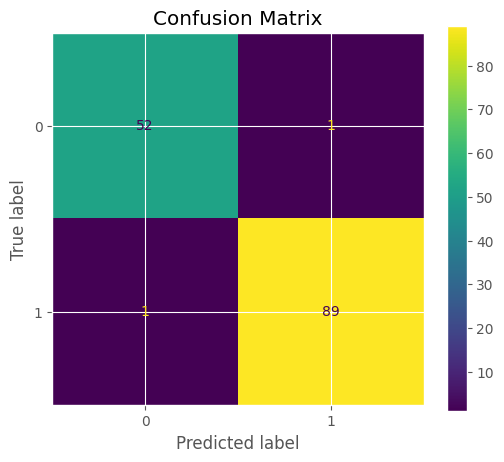

In [4]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test,pred,ax=ax)
plt.title('Confusion Matrix')
plt.show()

**Description:** The confusion matrix shows true positives, true negatives, false positives, and false negatives.

## 4. ROC Curve

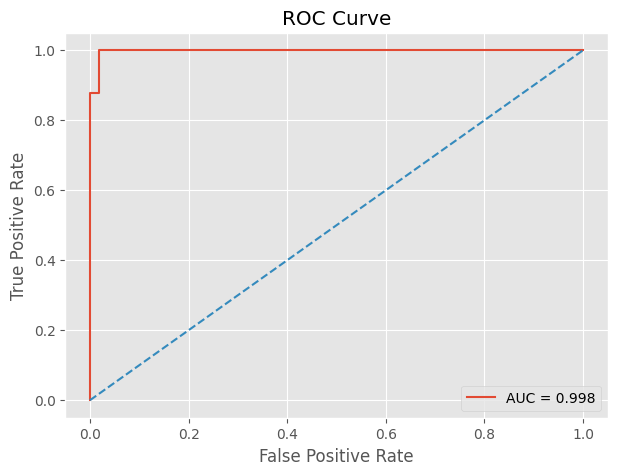

In [5]:
fpr, tpr, thresholds = roc_curve(y_test, proba)
roc_auc = auc(fpr,tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label='AUC = %.3f' % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**Description:** ROC curve evaluates classification quality across different thresholds. Higher AUC indicates better separability.

## 5. Probability Distribution

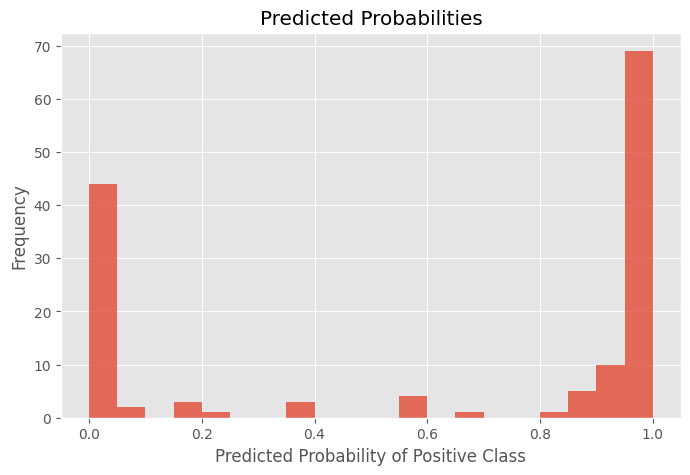

In [6]:
plt.figure(figsize=(8,5))
plt.hist(proba, bins=20, alpha=0.8)
plt.xlabel('Predicted Probability of Positive Class')
plt.ylabel('Frequency')
plt.title('Predicted Probabilities')
plt.show()

**Description:** Logistic Regression outputs probabilities, not only labels. Thresholds can be adjusted depending on business or medical priorities.

## Important Theory Concepts
- **Sigmoid Function:** Converts linear score into probability.
- **Decision Threshold:** Usually 0.5 but can be adjusted.
- **Odds and Log-Odds:** Core mathematical basis of logistic regression.
- **Regularization:** Prevents overfitting.
- **Multiclass Extension:** One-vs-Rest or multinomial logistic regression.

## Interpretation of Results
High accuracy and a strong ROC-AUC indicate the model separates classes effectively. Threshold tuning can improve recall or precision depending on the objective.

## Summary
Logistic Regression is a fast, interpretable, and powerful baseline for classification tasks. It is widely used in medicine, finance, fraud detection, and customer analytics.

## Conclusion
When you need probability estimates, interpretability, and efficient training, Logistic Regression is often one of the best first models to try.